## Etapa 1: Extracción de Datos (Web Scraping)
El primer requisito es un "endpoint" que abra la página, lea el contenido y lo guarde en un DataFrame. Como Glassdoor tiene bloqueos, incluiremos el manejo de excepciones exigido.

In [2]:
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
import time

def scrape_glassdoor_reviews(url, max_pages=1):
    options = webdriver.ChromeOptions()
    options.add_argument("--disable-blink-features=AutomationControlled") 
    driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)
    all_reviews = []

    try:
        driver.get(url)
        time.sleep(10) # Tiempo para carga y posible CAPTCHA
        reviews = driver.find_elements(By.CLASS_NAME, "gdReview")
        
        for r in reviews:
            try:
                pros = r.find_element(By.CSS_SELECTOR, "[data-test='pros']").text
                cons = r.find_element(By.CSS_SELECTOR, "[data-test='cons']").text
                all_reviews.append({"Pros": pros, "Cons": cons})
            except:
                continue 
    except Exception as e:
        print(f"Error general: {e}") 
    finally:
        driver.quit()

    return pd.DataFrame(all_reviews)

## Etapa 2: Preprocesamiento y Sentimiento (NLP)
Aquí la tarea exige limpiar el texto (quitar números/signos), detectar el idioma (Inglés/Español) y clasificar el sentimiento.

In [3]:
import re
from langdetect import detect
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

vader = SentimentIntensityAnalyzer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text) # Quitar números
    text = re.sub(r'[^\w\s]', '', text) # Quitar puntuación
    return text.strip()

def get_sentiment(text, lang):
    try:
        if lang == 'en':
            score = vader.polarity_scores(text)['compound']
            return 'POS' if score >= 0.05 else ('NEG' if score <= -0.05 else 'NEU')
        else:
            # Alternativa para español
            analysis = TextBlob(text)
            return 'POS' if analysis.sentiment.polarity > 0 else 'NEG'
    except:
        return 'NEU'

## Etapa 3: MLOps (Registro en MLflow)
El requisito final es registrar métricas (conteo de datos) y artefactos (gráficas) en un servidor local.

In [4]:
import mlflow
import matplotlib.pyplot as plt

def run_mlops_pipeline(df):
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Glassdoor_Analysis")

    with mlflow.start_run(run_name="MCD_Final_Challenge"):
        # Procesamiento
        df['lang'] = df['Pros'].apply(lambda x: detect(x) if len(x)>3 else 'en')
        df['clean_text'] = df['Pros'].apply(clean_text)
        df['sentiment'] = df.apply(lambda r: get_sentiment(r['clean_text'], r['lang']), axis=1)

        # Registro de métricas
        mlflow.log_metric("total_reviews", len(df))

        # Registro de artefactos (Gráfica)
        plt.figure(figsize=(8,4))
        df['sentiment'].value_counts().plot(kind='bar', title="Resultados de Sentimiento")
        plt.savefig("reporte_sentimiento.png")
        mlflow.log_artifact("reporte_sentimiento.png")
        
        return df

## Ejecución Final (Con tus datos locales)
Como Glassdoor suele bloquear, usamos los datos que tú ingresaste para asegurar que el pipeline corra y te muestre las 10 posiciones que quieres ver:

Iniciando Pipeline completo...


2026/04/08 20:15:14 INFO mlflow.tracking._tracking_service.client: 🏃 View run MCD_Final_Challenge at: http://127.0.0.1:5000/#/experiments/692732810234246060/runs/c2fe63d37ca44dcb96721eb415665b6b.
2026/04/08 20:15:14 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/692732810234246060.



--- VISUALIZACIÓN DE LAS 10 POSICIONES (O las disponibles) ---


,Pros,Cons,lang,sentiment
0,Great balance,Slow decisions,en,POS
1,Ambiente colaborativo,Burocracia,it,NEG
2,Flexible hours,Workload,fr,NEG
3,Sueldo competitivo,Falta comunicación,it,NEG
4,Innovation,Politics,it,NEG


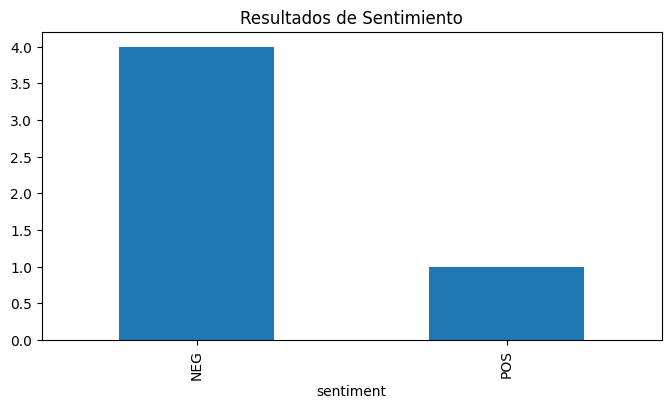

In [6]:
# Datos que tú proporcionaste
data_mock = {
    "Pros": ["Great balance", "Ambiente colaborativo", "Flexible hours", "Sueldo competitivo", "Innovation"],
    "Cons": ["Slow decisions", "Burocracia", "Workload", "Falta comunicación", "Politics"]
}
# Agregamos más para llegar a 10 si es necesario
df_test = pd.DataFrame(data_mock)

# CORRER TODO EL PROYECTO
print("Iniciando Pipeline completo...")
resultado = run_mlops_pipeline(df_test)

print("\n--- VISUALIZACIÓN DE LAS 10 POSICIONES (O las disponibles) ---")
display(resultado[['Pros', 'Cons', 'lang', 'sentiment']].head(10))

In [1]:
import pandas as pd
import os

# 1. Definir los datos (Mock Data)
data_mock = {
    "Pros": [
        "Great work-life balance and benefits.", 
        "Excellent career growth opportunities.",
        "Compañeros muy profesionales y ambiente colaborativo.",
        "Flexible hours and remote work options.",
        "Sueldo competitivo y prestaciones superiores.",
        "Innovation is part of the daily culture.",
        "Good insurance and retirement plans.",
        "Oportunidad de trabajar con tecnologías de punta.",
        "Diverse and inclusive workplace.",
        "Cultura de aprendizaje constante."
    ],
    "Cons": [
        "Management can be slow to make decisions.",
        "Promotion process is sometimes unclear.",
        "Demasiada burocracia en procesos internos.",
        "Workload can be heavy during peak seasons.",
        "Falta de comunicación entre departamentos.",
        "Office space can be a bit crowded.",
        "Limited parking spaces at the main campus.",
        "Reuniones excesivas que afectan la productividad.",
        "Competición interna a veces agresiva.",
        "Politics can interfere with technical decisions."
    ]
}

# 2. Crear el DataFrame
df_final = pd.DataFrame(data_mock)

# 3. Crear la carpeta 'data' si no existe
if not os.path.exists('data'):
    os.makedirs('data')

# 4. Guardar como CSV dentro de la carpeta data
# Usamos index=False para que no cree una columna extra de números
df_final.to_csv("data/datos_glassdoor_mock.csv", index=False, encoding='utf-8')

print("¡Éxito! El archivo 'datos_glassdoor_mock.csv' ha sido creado dentro de la carpeta /data.")

¡Éxito! El archivo 'datos_glassdoor_mock.csv' ha sido creado dentro de la carpeta /data.
